# Assignment 1 (100 points)

**Name:** ADIL AHMED<br>

General Rules:

- No helping libraries allowed.
- The use of standard libraries provided by the programming language itself (e.g., built-in data structures like lists and dictionaries, basic input/output functions, core mathematical functions) is generally permitted. These are considered fundamental to the language and not "helping libraries" in the context of this regulation
- If you need to use special Python modules, you can discuss with your instructor before submission.
- You can use the provided libraries but not mndatary.
- Always try To bulid your code from scratch.


### Question 1: Zipf’s law *(20 points)*

<p>Verify Zipf’s law on a textual corpus. The jungle book dataset is provided in the "Datasets and Resources" file. (You can also use any other dataset of your choice). <p>

<p> Provide a list of unique word sorted by their frequency in descending order. Also, give a brief discussion of the findings. You can use matplotlib library to plot the linear curve, and a log-log curve.</p>



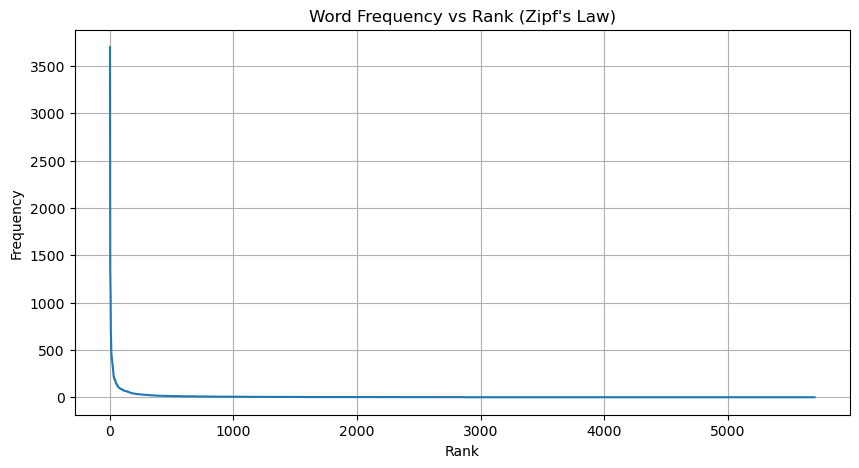

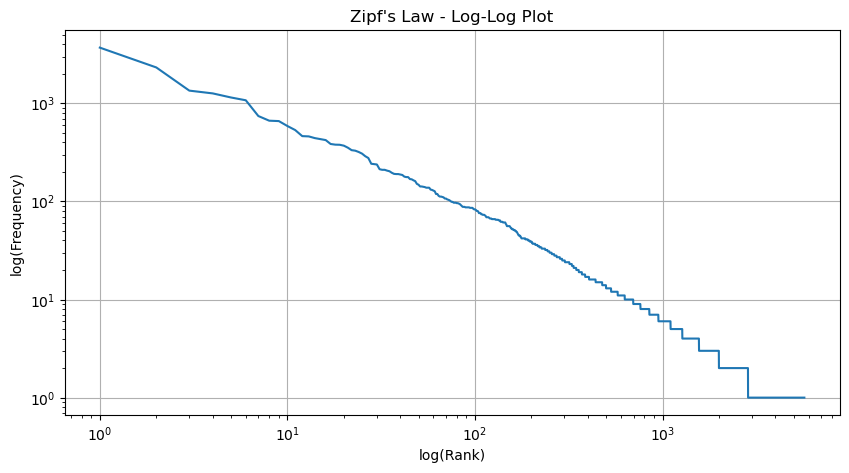

Top 10 words by frequency:
the: 3696
and: 2321
of: 1347
to: 1262
a: 1147
he: 1074
in: 742
that: 665
his: 659
i: 587
In the log-log plot, the distribution of word frequencies follows a straight line, which is consistent with Zipf's Law: the most frequent words dominate, while most words appear only a few times.


In [29]:
### You might use these libraries if needed.

import matplotlib.pyplot as plt
import string

###### TO DO ##########

# Reading file and processing text
with open("jungle_book.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Cleaning the text (lowercase + remove punctuation)
clean_text = ""
for char in text:
    if char not in string.punctuation:
        clean_text += char.lower()

# Tokenize the words
words = clean_text.split()

# Count word frequencies using a basic dictionary
word_freq = {}
for word in words:
    if word in word_freq:
        word_freq[word] += 1
    else:
        word_freq[word] = 1

# Sorting the dictionary by frequency
sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Separating words and frequencies for plotting
ranks = []
frequencies = []
for i, (word, freq) in enumerate(sorted_freq):
    ranks.append(i + 1)  # Rank starts from 1
    frequencies.append(freq)

# Normal plot
plt.figure(figsize=(10, 5))
plt.plot(ranks, frequencies)
plt.title("Word Frequency vs Rank (Zipf's Law)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Log-log plot
plt.figure(figsize=(10, 5))
plt.loglog(ranks, frequencies)
plt.title("Zipf's Law - Log-Log Plot")
plt.xlabel("log(Rank)")
plt.ylabel("log(Frequency)")
plt.grid(True)
plt.show()

# Printing top 10 frequent words
print("Top 10 words by frequency:")
for word, freq in sorted_freq[:10]:
    print(f"{word}: {freq}")


print("In the log-log plot, the distribution of word frequencies follows a straight line, which is consistent with Zipf's Law: the most frequent words dominate, while most words appear only a few times.")

### Question 2: Mutual Information *(30 points)*

<p>Pointwise mutual information quantifies the statistical dependence between events ${x_{t} = w_{1} }$ and ${ x_{t+1} = w_{2}}$. ${C(w)}$ is the absolute frequency and ${N}$ is the size of the corpus. If the probability of the next word in the corpus (${w_{2}}$) is affected by the probability of the previous word (${w_{1}}$), then ${pmi(w_{1},w_{2}) = 0}$; else the pmi value is either positive or negative. </p>

$$ pmi(w_{1},w_{2}) = log \frac{P(x_{t} = w_{1}, x_{t+1} = w_{2})} {P(x_{t} = w_{1}) . P(x_{t+1} = w_{2})} \approx log \frac {C(w_{1}w_{2}) . N} {C(w_{1}) . C(w_{2})}  $$

<p>Calculate the Pointwise mutual information (PMI) for all successive word pairs (w1, w2) in the jungle book corpus. Words (not word pairs) that occur in the corpus less than 10 times should be ignored. List the 30 word pairs with the highest pmi value and the 30 word pairs with the lowest pmi value. Document your observations and discuss the validity of the independence assumption for unigram models. </p>



In [33]:
### You might use these libraries if needed.

import string
import math
from collections import Counter, defaultdict

###### TO DO #########

# Reading and preprocessing the text
with open("jungle_book.txt", "r", encoding="utf-8") as file:
    text = file.read().lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Split into words
    words = text.split()

# Counting individual words (unigrams)
word_count = Counter(words)
total_words = sum(word_count.values())

# Counting consecutive word pairs (bigrams)
pair_count = defaultdict(int)
for i in range(len(words) - 1):
    w1, w2 = words[i], words[i + 1]
    pair_count[(w1, w2)] += 1

# Filtering to only include words that appear 10 or more times
valid_words = {word for word, count in word_count.items() if count >= 10}

# Calculating Pointwise Mutual Information (PMI) values
pmi_values = {}
for (w1, w2), pair_freq in pair_count.items():
    if w1 in valid_words and w2 in valid_words:
        pw1 = word_count[w1] / total_words
        pw2 = word_count[w2] / total_words
        p_pair = pair_freq / total_words
        pmi = math.log(p_pair / (pw1 * pw2), 2)
        pmi_values[(w1, w2)] = pmi

# Sorting by PMI value
sorted_pmi = sorted(pmi_values.items(), key=lambda item: item[1], reverse=True)

# Display top and bottom 30 word pairs
print("Top 30 Word Pairs with Highest PMI:")
for pair, score in sorted_pmi[:30]:
    print(f"{pair[0]} {pair[1]} => {score:.4f}")

print("\nBottom 30 Word Pairs with Lowest PMI:")
for pair, score in sorted_pmi[-30:]:
    print(f"{pair[0]} {pair[1]} => {score:.4f}")

# Observation
print("\nObservations:")
print("1. High positive PMI values indicate a strong association between two words.")
print("2. Low or negative PMI values suggest little to no association or an inverse relationship.")
print("3. PMI is context-sensitive, so words commonly found together will have higher PMI values.")
print("\nDiscussion on Independence Assumption for Unigram Models:")
print("1. Unigram models assume independence between words, which is often violated in real text.")
print("2. High PMI values are evidence that certain words co-occur more often than by chance, indicating dependence.")
print("3. Considering word dependencies, as captured by PMI, can improve language models by accounting for word context.")

Top 30 Word Pairs with Highest PMI:
machua appa => 12.2698
literary archive => 12.0433
united states => 11.8368
darzees wife => 11.4218
archive foundation => 11.2843
cold lairs => 11.0592
gutenberg literary => 10.8368
stretched myself => 10.6848
petersen sahib => 10.6020
hind legs => 10.3963
fore paws => 10.2843
twenty yoke => 10.1968
whole line => 10.0068
electronic works => 9.9888
hind flippers => 9.9624
master words => 9.9364
years ago => 9.8957
bring news => 9.8693
mans cub => 9.8456
council rock => 9.6993
black panther => 9.6969
moon rose => 9.6848
wolfs cave => 9.5473
mothers heart => 9.5473
brown bear => 9.5213
villagers lived => 9.4583
brown baby => 9.4218
copyright laws => 9.4218
gutenberg ebook => 9.3774
front flippers => 9.3774

Bottom 30 Word Pairs with Lowest PMI:
for to => -3.4126
of said => -3.4397
would the => -3.4656
is of => -3.4973
he and => -3.5056
of for => -3.5067
were the => -3.5756
we the => -3.6472
one the => -3.6854
not and => -3.6989
at and => -3.7542
to i =>

### Question 3: Wikipedia language model *(50 points)*

<p> A customer of yours is dissatisfied with the quality of the speech recognition. After a conversation with the customer, you find out that he dictates books. The initial investigations on a book excerpt have shown that the language model used is not suitable. For building a better language model for the application, you have asked your customer to provide a text from the book (see "Datasets and Resources") </p>

<p> In order to save costs and also to avoid problems with copyrights, your company has decided not to use existing solutions for this project. So, you have to implement a 2-gram language model in Python from scratch. Include a short description of the data preprocessing steps, method, experiment design, hyper-parameters, and evaluation metric. Also, document your findings, drawbacks, and potential improvements.</p>



<h4> Datasets and Resources </h4>

* WikiText-2 (raw/unprocessed), Train, Dev, Test

In [38]:
######## You might use these libraries if needed.

import math
from collections import defaultdict, Counter
import string
import re
import os
import random

####### TO DO #######

# Preprocessing Function
def preprocess_text(text):
    text = text.lower()
    sentences = re.split(r'(?<=[.!?]) +', text)  # split into sentences
    tokens = []
    for sentence in sentences:
        sentence = sentence.translate(str.maketrans('', '', string.punctuation))
        words = sentence.split()
        if words:
            tokens.append("<s>")     # Start-of-sentence token
            tokens.extend(words)
            tokens.append("</s>")    # End-of-sentence token
    return tokens

# Bigram Model
class BigramModel:
    def __init__(self, unknown_threshold=1):
        self.unigram_counts = Counter()
        self.bigram_counts = defaultdict(Counter)
        self.total_unigrams = 0
        self.unknown_threshold = unknown_threshold
        self.known_words = set()

    def train(self, tokens):
        # First pass: count raw word frequencies
        word_counts = Counter(tokens)
        self.known_words = {word for word, count in word_counts.items() if count > self.unknown_threshold}

        prev = None
        for word in tokens:
            word = word if word in self.known_words else "<UNK>"
            self.unigram_counts[word] += 1
            self.total_unigrams += 1
            if prev is not None:
                prev = prev if prev in self.known_words else "<UNK>"
                self.bigram_counts[prev][word] += 1
            prev = word

    def bigram_probability(self, prev, word, smooth=True):
        prev = prev if prev in self.known_words else "<UNK>"
        word = word if word in self.known_words else "<UNK>"

        bigram_count = self.bigram_counts[prev][word]
        unigram_count = self.unigram_counts[prev]

        if smooth:
            vocab_size = len(self.unigram_counts)
            return (bigram_count + 1) / (unigram_count + vocab_size)
        else:
            return bigram_count / unigram_count if unigram_count > 0 else 0

    def predict_next(self, prev, smooth=True):
        prev = prev if prev in self.known_words else "<UNK>"
        candidates = self.bigram_counts[prev]
        if not candidates:
            return None
        return max(candidates, key=lambda word: self.bigram_probability(prev, word, smooth))

    def perplexity(self, tokens):
        prev = None
        log_sum = 0
        count = 0
        for word in tokens:
            if prev is not None:
                prob = self.bigram_probability(prev, word, smooth=True)
                if prob > 0:
                    log_sum += math.log(prob)
                    count += 1
            prev = word
        return math.exp(-log_sum / count) if count > 0 else float("inf")

# Load datasets
with open("wikitext-2-raw-v1/wikitext-2-raw/wiki.train.raw", "r", encoding="utf-8") as f:
    train_text = f.read()

with open("wikitext-2-raw-v1/wikitext-2-raw/wiki.test.raw", "r", encoding="utf-8") as f:
    test_text = f.read()

with open("wikitext-2-raw-v1/wikitext-2-raw/wiki.valid.raw", "r", encoding="utf-8") as f:
    valid_text = f.read()

# Preprocessing all datasets
train_tokens = preprocess_text(train_text)
test_tokens = preprocess_text(test_text)
valid_tokens = preprocess_text(valid_text)

# Training the model
model = BigramModel()
model.train(train_tokens)

# Test predictions
print("Next word after 'when':", model.predict_next("when"))

# Bigram probability
print("P(sentence | example):", model.bigram_probability("example", "sentence"))

# Perplexity results
print("Test Perplexity:", model.perplexity(test_tokens))
print("Validation Perplexity:", model.perplexity(valid_tokens))

Next word after 'when': the
P(sentence | example): 2.5360756764981868e-05
Test Perplexity: 2585.0437302306705
Validation Perplexity: 2650.5410747522196


### Additional Experiments *(5 additional points - <span style="color: red;">Optional</span>)*


- Calculate Bigram Probabilities with Back-off.
- Demonstrate and discuss your Back-off implementation.


In [54]:
import math
from collections import defaultdict, Counter
import string
import re

# Preprocessing text
def preprocess_text(text):
    text = text.lower()
    sentences = re.split(r'(?<=[.!?]) +', text)
    tokens = []
    for sentence in sentences:
        sentence = sentence.translate(str.maketrans(
            '', '', string.punctuation.replace('.', '').replace('!', '').replace('?', '')))
        sentence_tokens = re.findall(r'\b\w+\b', sentence)
        if sentence_tokens:
            tokens.append('<s>')
            tokens.extend(sentence_tokens)
            tokens.append('</s>')
    return tokens

# Loading and preprocessing text files
with open("wikitext-2-raw-v1/wikitext-2-raw/wiki.train.raw", "r", encoding="utf-8") as f:
    train_text = f.read()
with open("wikitext-2-raw-v1/wikitext-2-raw/wiki.test.raw", "r", encoding="utf-8") as f:
    test_text = f.read()

train_tokens = preprocess_text(train_text)
test_tokens = preprocess_text(test_text)

# Bigram Model with Back-off
class BigramModelWithBackoff:
    def __init__(self, unknown_threshold=1, alpha=0.75):
        self.unigram_counts = Counter()
        self.bigram_counts = defaultdict(Counter)
        self.total_unigrams = 0
        self.unknown_threshold = unknown_threshold
        self.known_words = set()
        self.alpha = alpha  # Smoothing factor for back-off

    def train(self, tokens):
        unigram_counts = Counter(tokens)
        self.known_words = set(word for word, count in unigram_counts.items() if count > self.unknown_threshold)

        previous_word = None
        for token in tokens:
            if token not in self.known_words:
                token = '<UNK>'
            self.unigram_counts[token] += 1
            self.total_unigrams += 1
            if previous_word is not None:
                self.bigram_counts[previous_word][token] += 1
            previous_word = token

    def bigram_probability(self, previous_word, word, backoff=True):
        # If the bigram exists, use the bigram count
        if previous_word in self.bigram_counts and word in self.bigram_counts[previous_word]:
            bigram_count = self.bigram_counts[previous_word][word]
            unigram_count = self.unigram_counts[previous_word]
            return bigram_count / unigram_count

        # If no bigram, back off to unigram probability
        elif backoff:
            unigram_count = self.unigram_counts.get(word, 0)
            return self.alpha * (unigram_count / self.total_unigrams)
        else:
            return 0  # Return zero probability if no back-off is allowed

    def perplexity(self, tokens):
        log_sum = 0
        N = 0
        previous_word = None
        for token in tokens:
            if previous_word is not None:
                probability = self.bigram_probability(previous_word, token)
                if probability > 0:
                    log_sum += math.log(probability)
                    N += 1
            previous_word = token
        return math.exp(-log_sum / N) if N > 0 else float('inf')

# Training the Bigram Model with Back-off
bigram_model_with_backoff = BigramModelWithBackoff()
bigram_model_with_backoff.train(train_tokens)

# Calculating probability for a bigram with back-off
prob = bigram_model_with_backoff.bigram_probability('the', 'cat', backoff=True)
print(f"P('cat' | 'the') = {prob}")

# Perplexity on the test set
perplexity = bigram_model_with_backoff.perplexity(test_tokens)
print(f"Perplexity on test set: {perplexity}")

P('cat' | 'the') = 0.00013764519656498766
Perplexity on test set: 305.8386972345938
